# Sesión de clase 07 · Ejercicio 1: lexicón frente a TF-IDF + regresión logística

Dos formas clásicas de decidir si un texto es **negativo**, **neutro** o
**positivo**:

- **Lexicón con reglas (tipo VADER):** un diccionario de palabras con un
  puntaje de sentimiento (valencia) asignado a mano, más reglas fijas para
  la negación («no»), los intensificadores («muy») y el contraste («pero»).
  No aprende nada de los datos.
- **TF-IDF + regresión logística:** cada texto se convierte en un vector de
  pesos por palabra y un modelo lineal **aprende** de los ejemplos qué
  palabras empujan hacia cada clase.

Trabajamos con los **245 textos** del curso: `data/comentarios.csv` (135) y
`data/resenas_entrega.csv` (110), cada uno con la calificación de 1 a 5
estrellas que eligió el cliente.

**Etapas:** 1. Etiquetar · 2. Lexicón · 3. Modelo supervisado · 4. Comparar
· Discusión.

In [1]:
import math
import re
import unicodedata

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (ConfusionMatrixDisplay, accuracy_score,
                             classification_report, cohen_kappa_score,
                             confusion_matrix, f1_score)
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.pipeline import make_pipeline
from sklearn.utils.class_weight import compute_class_weight

pd.set_option("display.max_colwidth", 120)
CLASES = ["neg", "neu", "pos"]

## 1. Etiquetar: de estrellas a tres clases

**Supervisión débil:** las etiquetas salen de las estrellas que eligió el
cliente, no de un experto. 1–2★ → `neg`, 3★ → `neu`, 4–5★ → `pos`.

`pd.cut` con los cortes `[0, 2, 3, 5]` arma los intervalos `(0, 2]`, `(2, 3]`
y `(3, 5]`.

In [2]:
c = pd.read_csv("../data/comentarios.csv")
r = pd.read_csv("../data/resenas_entrega.csv")

df = pd.concat([c[["texto", "calificacion"]].assign(fuente="comentario"),
                r[["texto", "calificacion"]].assign(fuente="resena")],
               ignore_index=True)
df["y"] = pd.cut(df["calificacion"], [0, 2, 3, 5],
                 labels=CLASES).astype(str)

print(df.shape)
df.sample(5, random_state=7)

(245, 4)


,texto,calificacion,fuente,y
3,El envio internacional tardo mas dias de los indicados originalmente.,3,comentario,neu
82,El registro de cuenta pide demasiados datos para algo tan simple como crear un perfil. Preferiria un proceso mas cor...,3,comentario,neu
238,"La Xbox se actualizo sola apenas la conecte a internet, lista para jugar en poco tiempo.",5,resena,pos
80,El soporte por correo fue muy claro al explicarme las opciones de financiamiento.,5,comentario,pos
232,La Nikon Z50 cumplio todas mis expectativas para fotografia de viajes.,4,resena,pos


In [3]:
distribucion = pd.DataFrame({
    "textos": df["y"].value_counts(),
    "proporcion": df["y"].value_counts(normalize=True).round(3),
}).loc[["pos", "neg", "neu"]]
distribucion

,textos,proporcion
y,,
pos,126,0.514
neg,67,0.273
neu,52,0.212


**Desbalance:** responder siempre «positivo» ya acierta la mitad de las
veces sin leer nada. Esa es la línea base mínima que cualquier modelo debe
superar, y la razón por la que no basta con mirar la exactitud.

In [4]:
siempre_pos = np.full(len(df), "pos")
print(f"Exactitud de «siempre positivo»: {accuracy_score(df['y'], siempre_pos):.3f}")
print(f"Macro-F1  de «siempre positivo»: {f1_score(df['y'], siempre_pos, average='macro'):.3f}")

Exactitud de «siempre positivo»: 0.514
Macro-F1  de «siempre positivo»: 0.226


### ¿Qué revela una palabra? Probabilidad a partir de conteos

Antes de leer un texto, la probabilidad de que sea negativo es la proporción
de negativos (27 %). Si miramos solo los textos que contienen una expresión,
recalculamos esa proporción: cuánto se mueve dice cuánta evidencia aporta la
expresión.

In [5]:
def normalizar(texto):
    """Minúsculas y sin tildes: los textos del curso casi no las usan."""
    t = unicodedata.normalize("NFKD", texto.lower())
    return "".join(ch for ch in t if not unicodedata.combining(ch))

df["texto_norm"] = df["texto"].map(normalizar)

def evidencia(expresion):
    contiene = df["texto_norm"].str.contains(rf"\b{expresion}\b", regex=True)
    sub = df[contiene]
    return {"expresion": expresion,
            "textos": len(sub),
            "negativos": (sub["y"] == "neg").sum(),
            "P(neg | expresion)": round((sub["y"] == "neg").mean(), 2)}

pd.DataFrame([
    {"expresion": "(todos los textos)", "textos": len(df),
     "negativos": (df["y"] == "neg").sum(),
     "P(neg | expresion)": round((df["y"] == "neg").mean(), 2)},
    evidencia("tuve que"),
    evidencia("no"),
    evidencia("rapido"),
])

,expresion,textos,negativos,P(neg | expresion)
0,(todos los textos),245,67,0.27
1,tuve que,27,20,0.74
2,no,37,18,0.49
3,rapido,16,0,0.00


«tuve que» es evidencia fuerte de insatisfacción (3 de cada 4 textos que la
contienen son negativos). «no», en cambio, aparece en textos de todo tipo:
**la mitad** de los textos con «no» son neutros o positivos. Por eso falla
la regla «si contiene *no*, es negativo». «rapido» nunca aparece en un texto
negativo.

*Naive Bayes* combina esta evidencia de todas las palabras del texto y elige
la clase más probable.

## 2. Lexicón con reglas tipo VADER

Cuatro pasos: **tokenizar → buscar valencia → aplicar reglas → sumar y
normalizar**.

### 2.1 Actividad de la clase: tres frases a mano

Primero reproducimos la actividad de la diapositiva con un lexicón de cuatro
términos:

| Regla | Efecto |
| --- | --- |
| «muy» antes del término | suma 0.293 al valor absoluto |
| «no» antes del término | multiplica por −0.74 |
| «pero» | lo anterior × 0.5, lo posterior × 1.5 |
| Clase | suma > 0 positivo; < 0 negativo |

In [6]:
NEGADORES = {"no", "nunca", "ni", "sin"}
INTENSIFICADORES = {"muy": 0.293, "bastante": 0.293, "super": 0.293,
                    "algo": -0.293}            # «algo» atenúa
FACTOR_NEGACION = -0.74
VENTANA_NEGACION = 4       # «no» hasta 3 palabras antes del término
ALPHA = 15                 # constante de normalización de VADER


def tokenizar(texto):
    return re.findall(r"\w+", normalizar(texto))


def puntaje(texto, lexicon, negadores=NEGADORES):
    """Devuelve (suma, compuesto en [-1, 1], detalle por término)."""
    tokens = tokenizar(texto)
    pos_pero = tokens.index("pero") if "pero" in tokens else None
    detalle = []
    for i, tok in enumerate(tokens):
        if tok not in lexicon:
            continue
        v = lexicon[tok]
        aporte, mods = v, []
        if i > 0 and tokens[i - 1] in INTENSIFICADORES:
            aporte += math.copysign(INTENSIFICADORES[tokens[i - 1]], v)
            mods.append(f"«{tokens[i - 1]}»")
        if negadores & set(tokens[max(0, i - VENTANA_NEGACION):i]):
            aporte *= FACTOR_NEGACION
            mods.append("negación × (−0.74)")
        if pos_pero is not None:
            factor = 0.5 if i < pos_pero else 1.5
            aporte *= factor
            mods.append(f"{'antes' if i < pos_pero else 'después'} de «pero» × {factor}")
        detalle.append({"termino": tok, "v": v,
                        "modificador": ", ".join(mods) or "—",
                        "aporte": round(aporte, 3)})
    suma = sum(d["aporte"] for d in detalle)
    compuesto = suma / math.sqrt(suma ** 2 + ALPHA)
    return suma, compuesto, detalle

In [7]:
lexicon_actividad = {"rapida": 1.5, "malo": -2.5, "buen": 1.9, "pesima": -3.0}

for frase in ["La entrega fue muy rápida",
              "El producto no es malo",
              "Buen precio, pero la atención fue pésima"]:
    suma, _, detalle = puntaje(frase, lexicon_actividad)
    clase = "positivo" if suma > 0 else ("negativo" if suma < 0 else "neutro")
    print(f"«{frase}»  →  suma = {suma:+.3f}  →  {clase}")
    display(pd.DataFrame(detalle))

«La entrega fue muy rápida»  →  suma = +1.793  →  positivo


,termino,v,modificador,aporte
0,rapida,1.5,«muy»,1.793


«El producto no es malo»  →  suma = +1.850  →  positivo


,termino,v,modificador,aporte
0,malo,-2.5,negación × (−0.74),1.85


«Buen precio, pero la atención fue pésima»  →  suma = -3.550  →  negativo


,termino,v,modificador,aporte
0,buen,1.9,antes de «pero» × 0.5,0.95
1,pesima,-3.0,después de «pero» × 1.5,-4.50


«no es malo» (+1.85) obtiene **más** puntaje que «muy rápida» (+1.79): la
regla de negación convierte un término muy negativo en uno bastante positivo,
aunque un lector humano lo leería como «aceptable» a lo sumo.

### 2.2 Lexicón de 40 términos para la tienda

Valencias en escala −4 a +4 (como VADER). Los textos del curso vienen casi
sin tildes, por eso el lexicón y los textos se comparan ya normalizados.

In [8]:
LEXICON = {
    # positivos (21)
    "excelente": 3.2, "perfecto": 3.0, "perfecta": 3.0, "recomiendo": 2.0,
    "satisfecho": 2.0, "buena": 1.9, "buen": 1.9, "bueno": 1.9,
    "agradable": 1.9, "mejor": 1.8, "facil": 1.6, "bien": 1.5,
    "rapida": 1.5, "conforme": 1.5, "fluida": 1.4, "ayudo": 1.4,
    "util": 1.4, "sencillo": 1.3, "rapido": 1.2, "correctamente": 1.2,
    "completo": 1.0,
    # negativos (19)
    "pesima": -3.0, "pesimo": -3.0, "malo": -2.5, "mala": -2.5,
    "danado": -2.3, "fallo": -2.0, "retraso": -1.8, "error": -1.8,
    "incompleto": -1.8, "rayada": -1.8, "problema": -1.7, "lento": -1.5,
    "reclamo": -1.5, "dificil": -1.5, "dificiles": -1.5, "faltaba": -1.3,
    "tardo": -1.2, "confunde": -1.2, "innecesarios": -1.1,
}
print(len(LEXICON), "términos")

40 términos


Comprobamos el cálculo con los dos ejemplos de la clase: contraste con
«pero» y negación.

In [9]:
for frase in ["El diseño del sitio es agradable pero algunos textos son difíciles de leer",
              "El registro de cuenta fue rápido y no me pidieron datos innecesarios"]:
    suma, compuesto, detalle = puntaje(frase, LEXICON)
    print(f"«{frase}»\n  suma = {suma:+.2f}   compuesto = {compuesto:+.2f}")
    display(pd.DataFrame(detalle))

«El diseño del sitio es agradable pero algunos textos son difíciles de leer»
  suma = -1.30   compuesto = -0.32


,termino,v,modificador,aporte
0,agradable,1.9,antes de «pero» × 0.5,0.95
1,dificiles,-1.5,después de «pero» × 1.5,-2.25


«El registro de cuenta fue rápido y no me pidieron datos innecesarios»
  suma = +2.01   compuesto = +0.46


,termino,v,modificador,aporte
0,rapido,1.2,—,1.200
1,innecesarios,-1.1,negación × (−0.74),0.814


El **compuesto** lleva la suma a la escala −1 a +1 con
`suma / √(suma² + 15)`. La clase sale de un umbral de ±0.05: por encima es
positivo, por debajo negativo, y en medio (incluidos los textos sin ningún
término del lexicón) neutro.

In [10]:
UMBRAL = 0.05

def clase_lexicon(compuesto):
    if compuesto >= UMBRAL:
        return "pos"
    if compuesto <= -UMBRAL:
        return "neg"
    return "neu"

df["lex_compuesto"] = [puntaje(t, LEXICON)[1] for t in df["texto"]]
df["pred_lex"] = df["lex_compuesto"].map(clase_lexicon)

sin_terminos = (df["lex_compuesto"] == 0).sum()
print(f"Textos sin ningún término del lexicón: {sin_terminos} de {len(df)}")
print(classification_report(df["y"], df["pred_lex"], digits=3))

Textos sin ningún término del lexicón: 97 de 245
              precision    recall  f1-score   support

         neg      0.684     0.388     0.495        67
         neu      0.227     0.423     0.295        52
         pos      0.727     0.635     0.678       126

    accuracy                          0.522       245
   macro avg      0.546     0.482     0.490       245
weighted avg      0.609     0.522     0.547       245



## 3. Modelo supervisado: TF-IDF + regresión logística

- `TfidfVectorizer(ngram_range=(1, 2))`: palabras y pares de palabras
  («tuve que»); `min_df=2` descarta términos que aparecen en un solo texto;
  `sublinear_tf=True` usa `1 + log(tf)`.
- `LogisticRegression(class_weight="balanced")`: cada clase pesa
  `total ÷ (3 × textos de la clase)`, así un error en un neutro cuenta más.
- **Validación cruzada estratificada de 5 particiones:** cada texto se
  evalúa exactamente una vez con un modelo que no lo vio al entrenar.
- **Pipeline:** el TF-IDF se ajusta **dentro** de cada partición, solo con
  los textos de entrenamiento.

In [11]:
pesos = compute_class_weight("balanced", classes=np.array(CLASES), y=df["y"])
pd.DataFrame({"textos": df["y"].value_counts()[CLASES],
              "peso": pesos.round(2)}, index=CLASES)

,textos,peso
neg,67,1.22
neu,52,1.57
pos,126,0.65


In [12]:
modelo = make_pipeline(
    TfidfVectorizer(ngram_range=(1, 2), min_df=2, sublinear_tf=True),
    LogisticRegression(C=5, max_iter=2000, class_weight="balanced"),
)
cv = StratifiedKFold(5, shuffle=True, random_state=42)

df["pred_rl"] = cross_val_predict(modelo, df["texto"], df["y"], cv=cv)
print(classification_report(df["y"], df["pred_rl"], digits=3))
print(f"κ de Cohen = {cohen_kappa_score(df['y'], df['pred_rl']):.3f}")

              precision    recall  f1-score   support

         neg      0.708     0.687     0.697        67
         neu      0.408     0.385     0.396        52
         pos      0.809     0.841     0.825       126

    accuracy                          0.702       245
   macro avg      0.642     0.637     0.639       245
weighted avg      0.696     0.702     0.699       245

κ de Cohen = 0.512


### Fuga de información

Si el TF-IDF se ajusta con **los 245 textos** antes de dividir, el
vocabulario y los IDF de los textos de prueba se filtran al entrenamiento. La
métrica sube sin que el modelo sea mejor.

In [13]:
X_con_fuga = TfidfVectorizer(ngram_range=(1, 2), min_df=2,
                             sublinear_tf=True).fit_transform(df["texto"])
pred_fuga = cross_val_predict(
    LogisticRegression(C=5, max_iter=2000, class_weight="balanced"),
    X_con_fuga, df["y"], cv=cv)

print(f"Macro-F1 con Pipeline (correcto): {f1_score(df['y'], df['pred_rl'], average='macro'):.3f}")
print(f"Macro-F1 con fuga de información: {f1_score(df['y'], pred_fuga, average='macro'):.3f}")

Macro-F1 con Pipeline (correcto): 0.639
Macro-F1 con fuga de información: 0.687


### ¿Qué aprendió el modelo?

Ajustamos el pipeline con todos los textos solo para **inspeccionar** los
pesos (la evaluación ya se hizo con validación cruzada). Cada clase tiene su
propio vector de pesos: los más altos son las expresiones que más empujan
hacia esa clase.

In [14]:
modelo.fit(df["texto"], df["y"])
tfidf, rl = modelo.named_steps.values()
vocab = tfidf.get_feature_names_out()

top = {}
for k, clase in enumerate(rl.classes_):
    orden = np.argsort(rl.coef_[k])[::-1][:10]
    top[clase] = [f"{vocab[j]} ({rl.coef_[k][j]:+.2f})" for j in orden]
pd.DataFrame(top)

,neg,neu,pos
0,que (+2.08),aunque (+2.38),muy (+1.63)
1,mas de (+1.43),ni (+1.75),rapido (+1.45)
2,tuve que (+1.39),podria (+1.58),buena (+1.32)
3,tuve (+1.24),tiempo (+1.40),excelente (+1.28)
4,no (+1.23),funciona (+1.35),fue (+1.25)
5,un (+1.21),pero (+1.28),xiaomi (+1.13)
6,una (+1.15),actualizaciones (+1.24),de mi (+0.98)
7,llego con (+1.15),pero el (+1.24),bose (+0.81)
8,nuevo (+1.08),es (+1.22),fue muy (+0.80)
9,espera (+1.08),dias (+1.19),facil (+0.80)


- **«pero», «aunque» → neutro:** el contraste suele indicar una opinión
  mixta.
- **«tuve que» → negativo:** el esfuerzo extra del cliente es la señal más
  clara de insatisfacción.
- **Marcas → positivo:** con solo 245 textos, una marca frecuente en reseñas
  positivas (p. ej., «xiaomi») se vuelve «positiva». Es una **correlación
  espuria**.

## 4. Comparar

In [15]:
def metricas(y, pred):
    return {"exactitud": accuracy_score(y, pred),
            "macro-F1": f1_score(y, pred, average="macro"),
            "κ de Cohen": cohen_kappa_score(y, pred)}

pd.DataFrame({
    "siempre positivo": metricas(df["y"], siempre_pos),
    "lexicón (40 términos)": metricas(df["y"], df["pred_lex"]),
    "TF-IDF + RL": metricas(df["y"], df["pred_rl"]),
}).T.round(3)

,exactitud,macro-F1,κ de Cohen
siempre positivo,0.514,0.226,0.000
lexicón (40 términos),0.522,0.490,0.257
TF-IDF + RL,0.702,0.639,0.512


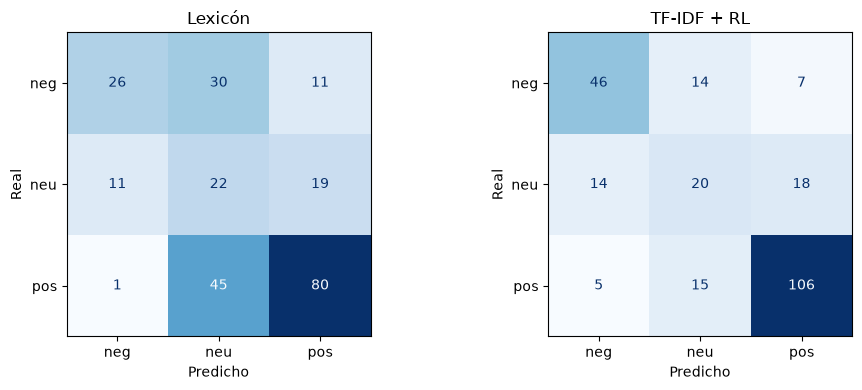

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, col, titulo in [(axes[0], "pred_lex", "Lexicón"),
                        (axes[1], "pred_rl", "TF-IDF + RL")]:
    ConfusionMatrixDisplay.from_predictions(
        df["y"], df[col], labels=CLASES, ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(titulo)
    ax.set_xlabel("Predicho")
    ax.set_ylabel("Real")
plt.tight_layout()
plt.show()

### Cinco errores de cada enfoque

Mostramos los errores **más graves** de cada uno: los que confunden
positivo con negativo (o viceversa); si no alcanzan, se completan con los de
mayor puntaje del lexicón en la dirección equivocada.

In [17]:
polaridad = (df["calificacion"] - 3) / 2          # −1 … +1
distancia = lambda a, b: abs(CLASES.index(a) - CLASES.index(b))

errores_lex = df[df["y"] != df["pred_lex"]].assign(
    gravedad=lambda d: [distancia(a, b) for a, b in zip(d["y"], d["pred_lex"])],
    desvio=lambda d: (d["lex_compuesto"] - polaridad[d.index]).abs())
errores_lex.sort_values(["gravedad", "desvio"], ascending=False).head(5)[
    ["calificacion", "y", "pred_lex", "lex_compuesto", "texto"]].round(2)

,calificacion,y,pred_lex,lex_compuesto,texto
38,1,neg,pos,0.36,Pedi una factura por RUC y me la enviaron con datos incorrectos dos veces seguidas. Recien a la tercera solicitud lo...
119,1,neg,pos,0.36,"Intente hacer una devolucion y el proceso fue confuso, nadie me explico bien los pasos."
66,1,neg,pos,0.25,El sitio me cerro sesion a mitad del pago y perdi el carrito completo que habia armado. Tuve que rehacer todo el ped...
69,1,neg,pos,0.25,"El sitio se desconecto varias veces durante el checkout un dia de alta demanda, tuve que reiniciar el proceso completo."
204,2,neg,pos,0.44,"El Moto G84 llego con la caja abierta, aunque el equipo en si estaba en buen estado."


In [18]:
proba = cross_val_predict(modelo, df["texto"], df["y"], cv=cv,
                          method="predict_proba")
df["rl_confianza"] = proba.max(axis=1)

errores_rl = df[df["y"] != df["pred_rl"]].assign(
    gravedad=lambda d: [distancia(a, b) for a, b in zip(d["y"], d["pred_rl"])])
errores_rl.sort_values(["gravedad", "rl_confianza"], ascending=False).head(5)[
    ["calificacion", "y", "pred_rl", "rl_confianza", "texto"]].round(2)

,calificacion,y,pred_rl,rl_confianza,texto
177,4,pos,neg,0.67,El television Hisense llego bien protegido con espuma adicional en las esquinas. Solo tuve que esperar un poco mas d...
74,2,neg,pos,0.63,El precio de envio internacional me parecio elevado comparado con tiendas similares de la region. El resto del proce...
119,1,neg,pos,0.61,"Intente hacer una devolucion y el proceso fue confuso, nadie me explico bien los pasos."
97,1,neg,pos,0.60,"Mi cupon de bienvenida expiro antes de poder usarlo, la vigencia era demasiado corta para el tramite que exigian."
78,4,pos,neg,0.54,Buena experiencia usando el asistente virtual para resolver dudas rapidas sobre garantia. Respondio en segundos y no...


### ¿En qué clase fallan ambos?

In [19]:
aciertos = pd.DataFrame({
    "lexicón": df["y"] == df["pred_lex"],
    "TF-IDF + RL": df["y"] == df["pred_rl"],
    "ambos fallan": (df["y"] != df["pred_lex"]) & (df["y"] != df["pred_rl"]),
    "y": df["y"],
}).groupby("y").mean().round(2)
aciertos.rename(columns={"lexicón": "exhaustividad lexicón",
                         "TF-IDF + RL": "exhaustividad TF-IDF + RL"})

,exhaustividad lexicón,exhaustividad TF-IDF + RL,ambos fallan
y,,,
neg,0.39,0.69,0.22
neu,0.42,0.38,0.31
pos,0.63,0.84,0.06


In [20]:
df[(df["y"] == "neu") & (df["pred_lex"] != "neu") & (df["pred_rl"] != "neu")][
    ["calificacion", "pred_lex", "pred_rl", "texto"]].head(6)

,calificacion,pred_lex,pred_rl,texto
1,3,neg,pos,"En general cumple lo que promete, ni mejor ni peor que otras tiendas de tecnologia que he probado."
3,3,neg,neg,El envio internacional tardo mas dias de los indicados originalmente.
41,3,pos,pos,"El soporte responde en tiempos razonables, ni muy rapido ni muy lento comparado con otras tiendas."
46,3,pos,pos,La app movil a veces se cierra sola cuando cambio de pantalla muy rapido. Fuera de eso funciona bien para navegar el...
49,3,pos,pos,La variedad de categorias es buena aunque siento que podria ampliarse un poco mas en accesorios.
51,3,pos,pos,"Las opciones de pago en cuotas varian bastante segun el banco, seria bueno mas claridad."


## Discusión

### ¿Qué ocurre si «no» se elimina como palabra vacía?

Las listas de *stopwords* en español (NLTK, spaCy) incluyen «no». Probamos
los dos enfoques sin esa palabra.

In [21]:
STOPWORDS_ES = ["el", "la", "los", "las", "de", "del", "y", "en", "un", "una",
                "que", "a", "se", "por", "con", "para", "mi", "me", "es",
                "fue", "lo", "al", "su", "no"]

variantes = {}
for nombre, stop in [("con «no»", [w for w in STOPWORDS_ES if w != "no"]),
                     ("sin «no»", STOPWORDS_ES)]:
    m = make_pipeline(
        TfidfVectorizer(ngram_range=(1, 2), min_df=2, sublinear_tf=True,
                        stop_words=stop),
        LogisticRegression(C=5, max_iter=2000, class_weight="balanced"))
    p = cross_val_predict(m, df["texto"], df["y"], cv=cv)
    variantes[f"TF-IDF + RL {nombre}"] = metricas(df["y"], p)

p_sin_neg = [clase_lexicon(puntaje(t, LEXICON, negadores=set())[1]) for t in df["texto"]]
variantes["lexicón con negación"] = metricas(df["y"], df["pred_lex"])
variantes["lexicón sin negación"] = metricas(df["y"], p_sin_neg)

pd.DataFrame(variantes).T.round(3)

,exactitud,macro-F1,κ de Cohen
TF-IDF + RL con «no»,0.706,0.655,0.519
TF-IDF + RL sin «no»,0.698,0.647,0.503
lexicón con negación,0.522,0.490,0.257
lexicón sin negación,0.494,0.459,0.214


Preguntas para el grupo:

- Sin la regla de negación, «no me pidieron datos innecesarios» o «llegó
  sin ningún daño» suman como negativos. ¿Cuántos textos cambian de clase
  en el lexicón? ¿Por qué el TF-IDF es menos sensible a quitar «no»?
- La clase **neutra** es la más difícil para ambos enfoques: mezcla elogios
  y quejas en el mismo texto (3★). ¿Es un problema del modelo o de la
  etiqueta?
- Revisen los errores del lexicón: ¿cuántos se deben a palabras que no
  están en el diccionario y cuántos a reglas mal aplicadas?

In [22]:
# Espacio para experimentar: agreguen términos al lexicón y vuelvan a medir
LEXICON_V2 = dict(LEXICON)
LEXICON_V2.update({"demora": -1.5, "cancele": -1.2})

pred_v2 = [clase_lexicon(puntaje(t, LEXICON_V2)[1]) for t in df["texto"]]
pd.DataFrame({"lexicón": metricas(df["y"], df["pred_lex"]),
              "lexicón v2": metricas(df["y"], pred_v2)}).T.round(3)

,exactitud,macro-F1,κ de Cohen
lexicón,0.522,0.490,0.257
lexicón v2,0.527,0.495,0.263
